libaraies

In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns
from scipy.stats import wilcoxon

# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

load files

In [2]:
# RESP FILE PATHS
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
BLRI_s3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"
BLRI_s4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"
RI1_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"
RI1_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5"
RI2_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"
RI1_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"
RI2_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"
RI1_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"
RI2_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5"
RI1_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5"
RI2_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"
RI1_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5"
RI2_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5"
RI2_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5"
RI1_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"


# BORIS CSVs (no comma at the end or it makes a tuple)
RI1_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv")
RI2_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv")
RI1_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv")
RI2_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")
RI1_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv")
RI2_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv")
RI1_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv")
RI2_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv")
RI1_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv")
RI2_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv")
RI1_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv")
RI2_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv")
RI1_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv")
RI2_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv")
RI2_3_5_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_5_p5_4_nRB3_20250621.csv")


In [3]:
ri1_h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,  
    "RI1_2_3": RI1_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
}

In [4]:
ri2_h5_paths = {
    "RI2_3_6": RI2_3_6_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [5]:
ri1_boris_data = {
    "RI1_3_6": RI1_3_6_boris.copy(),
    "RI1_4_7": RI1_4_7_boris.copy(),
    "RI1_2_3": RI1_2_3_boris.copy(),
    "RI1_4_8": RI1_4_8_boris.copy(),
    "RI1_1_1": RI1_1_1_boris.copy(),
    "RI1_1_2": RI1_1_2_boris.copy(),
    "RI1_2_4": RI1_2_4_boris.copy(),
}


In [6]:
ri2_boris_data = {
    "RI2_3_6": RI2_3_6_boris.copy(),
    "RI2_4_7": RI2_4_7_boris.copy(),
    "RI2_2_3": RI2_2_3_boris.copy(),
    "RI2_4_8": RI2_4_8_boris.copy(),
    "RI2_1_1": RI2_1_1_boris.copy(),
    "RI2_1_2": RI2_1_2_boris.copy(),
    "RI2_2_4": RI2_2_4_boris.copy(),
    "RI2_3_5": RI2_3_5_boris.copy(),
}


load_clean_resp_signal function for loading and preprocessing respiration data:

Reads raw resp signal and metadata from .h5

Computes original sampling rate (fs)

Applies a low-pass filter before downsampling to avoid aliasing

Downsamples the signal to your target_rate (default 100 Hz)

Applies a bandpass filter (0.1–20 Hz) with NeuroKit to clean the signal further

Creates a time vector that matches the cleaned signal length and sampling rate

This function returns:
rsp_cleaned: the cleaned, filtered, downsampled respiratory signal array

time_vector: time points corresponding to each sample in seconds

target_rate: the sampling rate after downsampling (e.g., 100 Hz)

You can then pass these outputs to functions like:
get_percent_change_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_start, sniff_end)

get_delta_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_end)

In [7]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal and time vector.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate

In [8]:
h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI2_3_6": RI2_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI1_2_3": RI1_2_3_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [9]:
resp_data = {}

for label, path in h5_paths.items():
    print(f"Processing {label}...")
    signal, time, rate = load_clean_resp_signal(path)
    
    if signal is not None:
        resp_data[label] = {
            "signal": signal,
            "time": time,
            "sampling_rate": rate
        }
    else:
        print(f"Skipping {label}: failed to load.")

print("✅ All available signals loaded.")


Processing RI1_3_6...
Processing RI2_3_6...
Processing RI1_4_7...
Processing RI2_4_7...
Processing RI1_2_3...
Processing RI2_2_3...
Processing RI1_4_8...
Processing RI2_4_8...
Processing RI1_1_1...
Processing RI2_1_1...
Processing RI1_1_2...
Processing RI2_1_2...
Processing RI1_2_4...
Processing RI2_2_4...
Processing RI1_3_5...
Processing RI2_3_5...
✅ All available signals loaded.


In [10]:
def extract_subject_body_sniffs(df):
    """
    Filters BORIS dataframe for body sniffing initiated by the subject.
    """
    df = df.copy()
    df['Start (s)'] = df['Start (s)'].astype(float)
    df['Stop (s)'] = df['Stop (s)'].astype(float)
    df = df.sort_values(by='Start (s)').reset_index(drop=True)

    # Filter for body sniffing by the subject
    subject_mask = df['Subject'].str.lower() == 'subject'
    sniff_mask = df['Behavior'].str.lower() == 'body sniffing'

    return df[subject_mask & sniff_mask]



ONE SUBJECT 3.6 WORKED

In [11]:
subject_body_sniffs = extract_subject_body_sniffs(RI2_3_6_boris)

print("\n🔍 Subject-Initiated Body Sniffs (RI2_3_6):")
print(subject_body_sniffs[['Subject', 'Behavior', 'Start (s)', 'Stop (s)']])


🔍 Subject-Initiated Body Sniffs (RI2_3_6):
    Subject       Behavior  Start (s)  Stop (s)
3   subject  body sniffing      8.700     9.367
4   subject  body sniffing     10.300    11.167
8   subject  body sniffing     21.067    21.200
10  subject  body sniffing     22.367    22.967
18  subject  body sniffing     34.833    40.633
19  subject  body sniffing     41.300    42.000
22  subject  body sniffing     50.900    52.167


RUN LOOP ON ALL SUBJECTS WORKS

In [12]:
all_subject_body_sniffs = []

# Process RI1 group
for label, boris_df in ri1_boris_data.items():
    sniffs = extract_subject_body_sniffs(boris_df)
    sniffs["Trial"] = label
    sniffs["Group"] = "RI1"
    all_subject_body_sniffs.append(sniffs)

# Process RI2 group
for label, boris_df in ri2_boris_data.items():
    sniffs = extract_subject_body_sniffs(boris_df)
    sniffs["Trial"] = label
    sniffs["Group"] = "RI2"
    all_subject_body_sniffs.append(sniffs)

# Combine into one DataFrame
combined_subject_body_sniffs_df = pd.concat(all_subject_body_sniffs, ignore_index=True)



In [13]:
combined_subject_body_sniffs_df

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop,Trial,Group,Media file,Total length,FPS,Modifiers
0,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,subject,22.135,body sniffing,Not defined,STATE,13.276,13.448,0.172,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,385.0,390.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
1,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,subject,22.135,body sniffing,Not defined,STATE,27.793,28.448,0.655,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,806.0,825.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
2,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,subject,22.135,body sniffing,Not defined,STATE,29.862,30.586,0.724,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,866.0,887.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
3,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,subject,22.135,body sniffing,Not defined,STATE,53.897,54.414,0.517,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,1563.0,1578.0,NaN,NaN,NaN,NaN,RI1_3_6,RI1,NaN,NaN,NaN,NaN
4,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.800,30.0,subject,47.492,body sniffing,Not defined,STATE,23.533,24.099,0.566,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,706.0,NaN,NaN,NaN,NaN,NaN,RI1_4_7,RI1,NaN,NaN,NaN,NaN
5,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.800,30.0,subject,47.492,body sniffing,Not defined,STATE,33.100,34.367,1.267,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,993.0,1031.0,NaN,NaN,NaN,NaN,RI1_4_7,RI1,NaN,NaN,NaN,NaN
6,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.800,30.0,subject,47.492,body sniffing,Not defined,STATE,39.900,40.767,0.867,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,1197.0,1223.0,NaN,NaN,NaN,NaN,RI1_4_7,RI1,NaN,NaN,NaN,NaN
7,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.800,30.0,subject,47.492,body sniffing,Not defined,STATE,57.733,58.332,0.599,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,1732.0,NaN,NaN,NaN,NaN,NaN,RI1_4_7,RI1,NaN,NaN,NaN,NaN
8,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.800,30.0,subject,47.492,body sniffing,Not defined,STATE,65.400,66.766,1.366,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,1962.0,NaN,NaN,NaN,NaN,NaN,RI1_4_7,RI1,NaN,NaN,NaN,NaN
9,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:

In [ ]:
def calculate_subject_body_sniff_resp_change_with_post(signal, time, sniff_start, sampling_rate=100, plot=True,
                                                       baseline_color='gray', sniff_color='black', post_color='red',
                                                       title=None):
    """
    Calculates respiration rate (Hz) before, during, and after a subject-initiated body sniff.

    Time Windows:
    - Baseline (Pre):   −5s to −1s before sniff_start
    - Sniff:             0s to +0.5s after sniff_start
    - Post-sniff:       +0.5s to +1s after sniff_start

    Returns:
        percent_change_sniff (float): % change sniff vs baseline
        percent_change_post (float): % change post vs baseline
        baseline_mean_rate (float)
        sniff_mean_rate (float)
        post_mean_rate (float)
    """
    # Time masks
    baseline_mask = (time >= sniff_start - 5) & (time < sniff_start - 1)
    sniff_mask = (time >= sniff_start) & (time < sniff_start + 0.5)
    post_mask = (time >= sniff_start + 0.5) & (time < sniff_start + 1.5)

    min_distance_samples = int(0.0833 * sampling_rate)  # ~75 ms

    def get_rate(segment_mask):
        segment = signal[segment_mask]
        peaks, _ = find_peaks(segment, distance=min_distance_samples)
        peak_times = time[segment_mask][peaks]
        ibis = np.diff(peak_times)
        if len(ibis) == 0:
            return None
        return np.mean(1 / ibis)

    baseline_rate = get_rate(baseline_mask)
    sniff_rate = get_rate(sniff_mask)
    post_rate = get_rate(post_mask)

    if None in (baseline_rate, sniff_rate, post_rate):
        if plot:
            print("⚠️ Not enough peaks detected in one or more windows.")
        return None, None, None, None, None

    # Compute percent changes
    percent_change_sniff = ((sniff_rate - baseline_rate) / baseline_rate) * 100
    percent_change_post = ((post_rate - baseline_rate) / baseline_rate) * 100

    if plot:
        plt.figure(figsize=(5, 4))
        plt.bar(['Pre-sniff', 'During Sniff', 'Post Sniff'],
                [baseline_rate, sniff_rate, post_rate],
                color=[baseline_color, sniff_color, post_color])
        plt.ylabel('Respiration Rate (Hz)')
        plt.title(title or f'Subject Body Sniff: Respiration Rate')
        plt.tight_layout()
        plt.show()

    return percent_change_sniff, percent_change_post, baseline_rate, sniff_rate, post_rate

In [15]:
subject_body_sniff_results = []

for i, sniff_row in combined_subject_body_sniffs_df.iterrows():
    trial = sniff_row["Trial"]
    sniff_start = sniff_row["Start (s)"]

    # Retrieve respiration signal
    resp_entry = resp_data.get(trial, None)
    if resp_entry is None:
        print(f"⚠️ Missing respiration data for {trial}, skipping...")
        continue

    signal = resp_entry["signal"]
    time = resp_entry["time"]
    sampling_rate = resp_entry["sampling_rate"]

    # Calculate respiration rate changes (pre, during, post)
    result = calculate_subject_body_sniff_resp_change_with_post(
        signal, time, sniff_start, sampling_rate=sampling_rate, plot=False
    )

    if result[0] is None:
        print(f"⚠️ Not enough peaks at {sniff_start}s in {trial}, skipping...")
        continue

    pct_change_sniff, pct_change_post, baseline_rate, sniff_rate, post_rate = result

    subject_body_sniff_results.append({
        "Trial": trial,
        "Sniff Start": sniff_start,
        "Percent Change Sniff": pct_change_sniff,
        "Percent Change Post": pct_change_post,
        "Baseline Rate": baseline_rate,
        "Sniff Rate": sniff_rate,
        "Post Rate": post_rate
    })

# Convert to DataFrame
subject_body_sniff_df = pd.DataFrame(subject_body_sniff_results)
print(subject_body_sniff_df.head())


⚠️ Not enough peaks at 305.077s in RI1_1_1, skipping...
⚠️ Not enough peaks at 358.846s in RI1_1_1, skipping...
     Trial  Sniff Start  Percent Change Sniff  Percent Change Post  \
0  RI1_3_6       13.276             -2.669301             8.276457   
1  RI1_3_6       27.793             -2.751738           -10.204180   
2  RI1_3_6       29.862             -0.860710            -0.860710   
3  RI1_3_6       53.897             30.148401            -2.994980   
4  RI1_4_7       23.533             -7.038996            -4.240839   

   Baseline Rate  Sniff Rate  Post Rate  
0       9.538808    9.284188  10.328283  
1      10.334894   10.050505   9.280303  
2       9.946724    9.861111   9.861111  
3       8.590621   11.180556   8.333333  
4      10.829638   10.067340  10.370370  


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30004\1006467179.py:46: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(


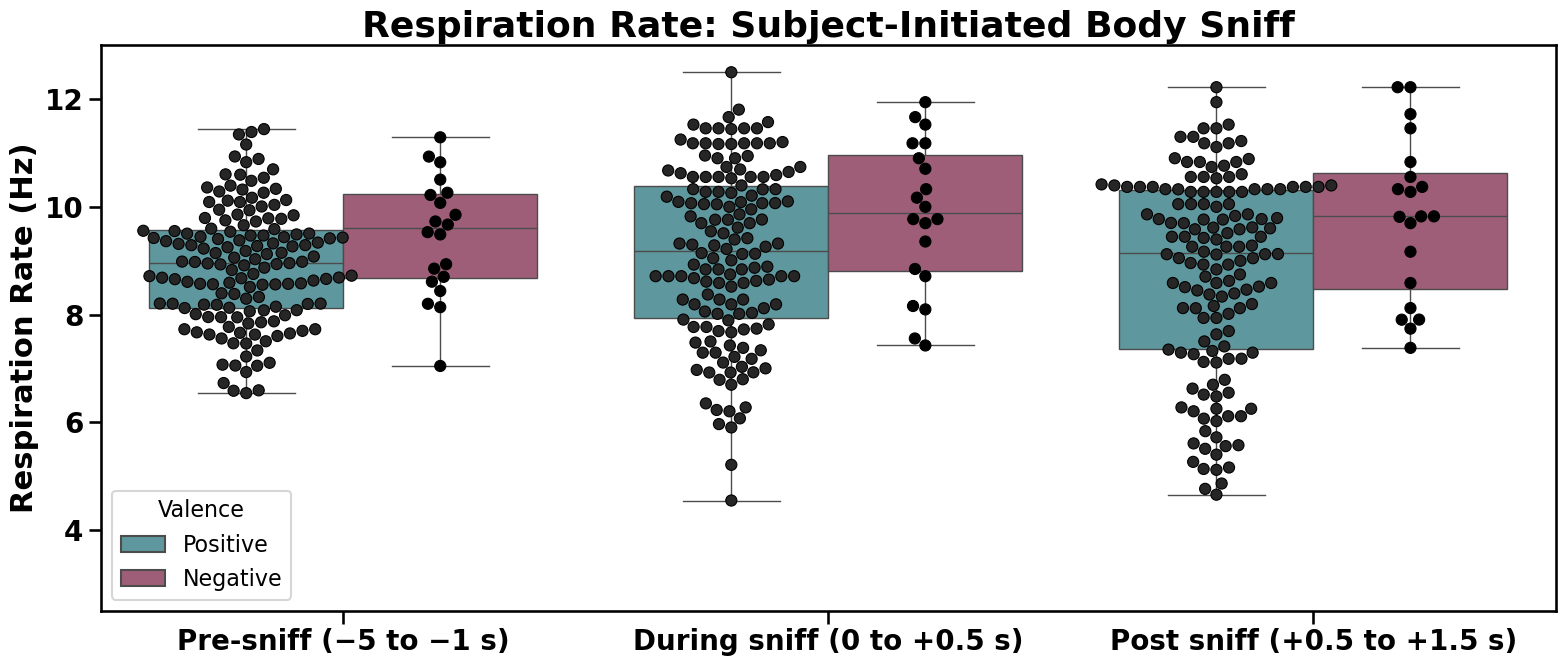

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define color palette
custom_palette = {
    'Positive': (83/255, 161/255, 169/255),  # RI1
    'Negative': (169/255, 83/255, 118/255)   # RI2
}

# Assign valence labels based on Trial
subject_body_sniff_df['Valence'] = subject_body_sniff_df['Trial'].apply(
    lambda x: 'Positive' if 'RI1' in x else ('Negative' if 'RI2' in x else 'Unknown')
)
subject_body_sniff_df = subject_body_sniff_df[subject_body_sniff_df['Valence'] != 'Unknown']

# Melt dataframe for plotting (include Post Rate)
plot_df = subject_body_sniff_df.melt(
    id_vars=["Trial", "Sniff Start", "Valence"],
    value_vars=["Baseline Rate", "Sniff Rate", "Post Rate"],
    var_name="Condition",
    value_name="Respiration Rate (Hz)"
)

# Rename conditions for clearer x-axis labels
plot_df["Condition"] = plot_df["Condition"].replace({
    "Baseline Rate": "Pre-sniff (−5 to −1 s)",
    "Sniff Rate": "During sniff (0 to +0.5 s)",
    "Post Rate": "Post sniff (+0.5 to +1.5 s)"
})

# Set up plot
plt.figure(figsize=(16, 7))
sns.set_context("talk")

# Boxplot by condition and valence
sns.boxplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    palette=custom_palette,
    fliersize=0
)

# Swarmplot overlay for individual data points
sns.swarmplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    dodge=True,
    color='black',
    edgecolor='black',
    alpha=1,
    size=8,
    marker='o',
    linewidth=0.8,
    legend=False  # Prevent duplicate legends
)

# Formatting
plt.title("Respiration Rate: Subject-Initiated Body Sniff", fontsize=26, weight='bold')
plt.ylabel("Respiration Rate (Hz)", fontsize=22, weight='bold')
plt.xlabel('')
plt.xticks(fontsize=20, weight='bold')
plt.yticks(ticks=[4, 6, 8, 10, 12],fontsize=20, weight='bold')
plt.ylim(2.5, 13)

plt.legend(title='Valence', fontsize=16, title_fontsize=16, loc='lower left', bbox_to_anchor=(0, 0))

plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30004\1296791162.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Valence', fontsize=16, title_fontsize=16, loc='lower left', bbox_to_anchor=(0, 0))


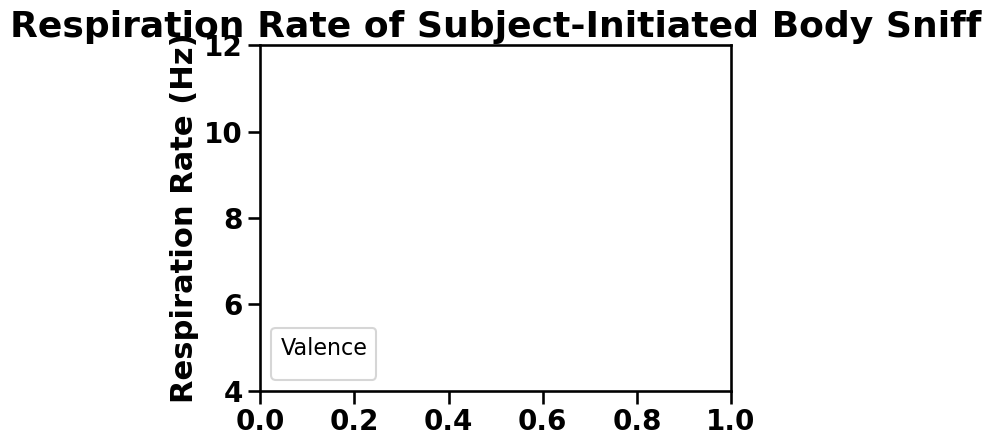

In [17]:
# Formatting
plt.title("Respiration Rate of Subject-Initiated Body Sniff", fontsize=26, weight='bold')
plt.ylabel("Respiration Rate (Hz)", fontsize=22, weight='bold')
plt.xlabel('')
plt.xticks(fontsize=20, weight='bold')
plt.yticks(ticks=[4, 6, 8, 10, 12], fontsize=20, weight='bold')
plt.ylim(4, 12)

plt.legend(title='Valence', fontsize=16, title_fontsize=16, loc='lower left', bbox_to_anchor=(0, 0))

plt.tight_layout()
plt.show()
